# HIT140 Objective 2 — Linear Regression 2.1
**Question:** Can pre-match information predict the goal difference between two opposing teams in FIFA World Cup 2026 matches?

This notebook constructs the required 104-match dataset, engineers exactly eight pre-match explanatory variables, performs exploratory analysis, fits competing linear models, evaluates them on a chronological hold-out set, and checks regression diagnostics.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## 1. Load the raw match dataset
Place `dataset 2.1.xlsx` in the same folder as this notebook, or change the path below. The raw file is kept unchanged; all cleaning is performed in Python.


In [2]:
raw = pd.read_excel("dataset 2.1.xlsx")
print("Raw shape:", raw.shape)
raw.head()


Raw shape: (107, 13)


,Round,Wk,Day,Date,Time,Home,Score,Away,Attendance,Venue,Referee,Match Report,Notes
0,Group stage,1.0,Thu,2026-06-11,13:00 (04:30),Mexico mx,2–0,za South Africa,80824.0,Estadio Banorte (Neutral Site),Wilton Sampaio,Match Report,NaN
1,Group stage,1.0,Thu,2026-06-11,20:00 (11:30),Korea Republic kr,2–1,cz Czechia,44985.0,Estadio Akron (Neutral Site),Amin Omar,Match Report,NaN
2,Group stage,1.0,Fri,2026-06-12,15:00 (04:30),Canada ca,1–1,ba Bosnia–Herz,43002.0,BMO Field (Neutral Site),Facundo Tello,Match Report,NaN
3,Group stage,1.0,Fri,2026-06-12,18:00 (10:30),USA us,4–1,py Paraguay,70492.0,SoFi Stadium (Neutral Site),Danny Makkelie,Match Report,NaN
4,Group stage,1.0,Sat,2026-06-13,12:00 (04:30),Qatar qa,1–1,ch Switzerland,67966.0,Levi's Stadium (Neutral Site),Said Martínez,Match Report,NaN


In [3]:
# Remove the three blank separator rows.
matches = raw.dropna(how="all").reset_index(drop=True)
assert len(matches) == 104, f"Expected 104 matches, found {len(matches)}"
print("Cleaned shape:", matches.shape)


Cleaned shape: (104, 13)


## 2. Clean team names and scores
FBref includes short country codes in team names. These are standardised so that ranking and age data merge consistently. Penalty shoot-out kicks are not treated as match goals; for shoot-out matches the regulation/extra-time match score is used.


In [4]:
aliases = {
    "England eng":"England","eng England":"England","Scotland sct":"Scotland","sct Scotland":"Scotland",
    "Bosnia–Herz":"Bosnia and Herzegovina","Cabo Verde":"Cape Verde","Congo DR":"DR Congo",
    "Côte d'Ivoire":"Ivory Coast","IR Iran":"Iran","Korea Republic":"South Korea","USA":"United States"
}
def clean_team(s):
    s = str(s).strip()
    s = __import__("re").sub(r"^[a-z]{2}\s+", "", s)
    s = __import__("re").sub(r"\s+[a-z]{2}$", "", s)
    return aliases.get(s, s)

matches["Home"] = matches["Home"].apply(clean_team)
matches["Away"] = matches["Away"].apply(clean_team)

def parse_score(s):
    nums = [int(x) for x in __import__("re").findall(r"\d+", str(s))]
    if len(nums) >= 4 and "(" in str(s):
        return nums[1], nums[2]
    return nums[0], nums[1]

matches[["Home_Goals","Away_Goals"]] = matches["Score"].apply(lambda s: pd.Series(parse_score(s)))
matches["Goal_Difference"] = matches["Home_Goals"] - matches["Away_Goals"]
matches[["Home","Score","Away","Home_Goals","Away_Goals","Goal_Difference"]].head()


,Home,Score,Away,Home_Goals,Away_Goals,Goal_Difference
0,Mexico,2–0,South Africa,2,0,2
1,South Korea,2–1,Czechia,2,1,1
2,Canada,1–1,Bosnia and Herzegovina,1,1,0
3,United States,4–1,Paraguay,4,1,3
4,Qatar,1–1,Switzerland,1,1,0


## 3. Pre-tournament team information
`Rank_Diff` uses the FIFA men's ranking published on 11 June 2026. `Age_Diff` uses the mean age of each official 26-player World Cup squad. These values were available before the tournament.


In [5]:
ranks = {
  "Argentina": 1,
  "Spain": 2,
  "France": 3,
  "England": 4,
  "Portugal": 5,
  "Brazil": 6,
  "Morocco": 7,
  "Netherlands": 8,
  "Belgium": 9,
  "Germany": 10,
  "Croatia": 11,
  "Colombia": 13,
  "Mexico": 14,
  "Senegal": 15,
  "Uruguay": 16,
  "United States": 17,
  "Japan": 18,
  "Switzerland": 19,
  "Iran": 20,
  "Türkiye": 22,
  "Ecuador": 23,
  "Austria": 24,
  "South Korea": 25,
  "Australia": 27,
  "Algeria": 28,
  "Egypt": 29,
  "Canada": 30,
  "Norway": 31,
  "Ivory Coast": 33,
  "Panama": 34,
  "Sweden": 38,
  "Czechia": 40,
  "Paraguay": 41,
  "Scotland": 42,
  "Tunisia": 45,
  "DR Congo": 46,
  "Uzbekistan": 50,
  "Qatar": 56,
  "Iraq": 57,
  "South Africa": 60,
  "Saudi Arabia": 61,
  "Jordan": 63,
  "Bosnia and Herzegovina": 64,
  "Cape Verde": 67,
  "Ghana": 73,
  "Curaçao": 82,
  "Haiti": 83,
  "New Zealand": 85
}

ages = {
  "Panama": 30.0,
  "Iran": 29.8,
  "Colombia": 29.6,
  "Cape Verde": 29.2,
  "Qatar": 28.9,
  "Scotland": 28.7,
  "Egypt": 28.7,
  "Brazil": 28.7,
  "Argentina": 28.6,
  "Paraguay": 28.5,
  "DR Congo": 28.5,
  "Uruguay": 28.2,
  "Austria": 28.1,
  "Jordan": 28.1,
  "Saudi Arabia": 28.0,
  "Uzbekistan": 28.0,
  "Croatia": 27.9,
  "Switzerland": 27.8,
  "New Zealand": 27.6,
  "Curaçao": 27.5,
  "Portugal": 27.5,
  "Germany": 27.5,
  "Mexico": 27.5,
  "South Korea": 27.5,
  "Netherlands": 27.3,
  "Czechia": 27.2,
  "Türkiye": 27.2,
  "Japan": 27.2,
  "Belgium": 27.1,
  "Haiti": 27.1,
  "Sweden": 27.0,
  "Australia": 26.9,
  "Iraq": 26.7,
  "Senegal": 26.6,
  "England": 26.6,
  "France": 26.6,
  "Algeria": 26.5,
  "United States": 26.4,
  "Canada": 26.4,
  "Ghana": 26.4,
  "South Africa": 26.3,
  "Norway": 26.3,
  "Spain": 26.2,
  "Tunisia": 26.2,
  "Morocco": 25.9,
  "Bosnia and Herzegovina": 25.9,
  "Ecuador": 25.6,
  "Ivory Coast": 25.3
}

assert set(matches['Home']).union(matches['Away']) == set(ranks) == set(ages)


## 4. Engineer exactly eight pre-match explanatory variables

The eight predictors are:

1. `Rank_Diff`
2. `Age_Diff`
3. `Goals_For_Avg_Diff`
4. `Goals_Against_Avg_Diff`
5. `Win_Rate_Diff`
6. `Draw_Rate_Diff`
7. `Clean_Sheet_Rate_Diff`
8. `Last_Match_GD_Diff`

For a team's first tournament match, tournament-history measures are set to 0 because no 2026 World Cup performance had yet been observed. The value represents *absence of prior tournament evidence*, not assumed average performance.


In [6]:
from collections import defaultdict

history = defaultdict(lambda: {"mp":0,"gf":0,"ga":0,"wins":0,"draws":0,"clean":0,"lastgd":0})
rows = []

for idx, row in matches.iterrows():
    home, away = row["Home"], row["Away"]
    hg, ag = int(row["Home_Goals"]), int(row["Away_Goals"])

    def pre(team):
        h = history[team]
        if h["mp"] == 0:
            return {"gf":0,"ga":0,"win":0,"draw":0,"clean":0,"lastgd":0}
        mp = h["mp"]
        return {
            "gf":h["gf"]/mp, "ga":h["ga"]/mp, "win":h["wins"]/mp,
            "draw":h["draws"]/mp, "clean":h["clean"]/mp, "lastgd":h["lastgd"]
        }

    ph, pa = pre(home), pre(away)
    rows.append({
        "Match_ID": idx + 1,
        "Date": row["Date"],
        "Round": row["Round"],
        "Home": home, "Away": away,
        "Home_Goals": hg, "Away_Goals": ag,
        "Goal_Difference": hg - ag,
        "Rank_Diff": ranks[home] - ranks[away],
        "Age_Diff": ages[home] - ages[away],
        "Goals_For_Avg_Diff": ph["gf"] - pa["gf"],
        "Goals_Against_Avg_Diff": ph["ga"] - pa["ga"],
        "Win_Rate_Diff": ph["win"] - pa["win"],
        "Draw_Rate_Diff": ph["draw"] - pa["draw"],
        "Clean_Sheet_Rate_Diff": ph["clean"] - pa["clean"],
        "Last_Match_GD_Diff": ph["lastgd"] - pa["lastgd"],
    })

    # Update histories only AFTER predictor values have been recorded.
    for team, gf, ga in [(home,hg,ag),(away,ag,hg)]:
        h = history[team]
        h["mp"] += 1; h["gf"] += gf; h["ga"] += ga; h["lastgd"] = gf - ga
        if ga == 0: h["clean"] += 1
        if gf > ga: h["wins"] += 1
        elif gf == ga: h["draws"] += 1

df = pd.DataFrame(rows)
predictors = ["Rank_Diff","Age_Diff","Goals_For_Avg_Diff","Goals_Against_Avg_Diff",
              "Win_Rate_Diff","Draw_Rate_Diff","Clean_Sheet_Rate_Diff","Last_Match_GD_Diff"]
assert df[predictors].shape == (104, 8)
df.head()


,Match_ID,Date,Round,Home,Away,Home_Goals,Away_Goals,Goal_Difference,Rank_Diff,Age_Diff,Goals_For_Avg_Diff,Goals_Against_Avg_Diff,Win_Rate_Diff,Draw_Rate_Diff,Clean_Sheet_Rate_Diff,Last_Match_GD_Diff
0,1,2026-06-11,Group stage,Mexico,South Africa,2,0,2,-46,1.2,0.0,0.0,0.0,0.0,0.0,0
1,2,2026-06-11,Group stage,South Korea,Czechia,2,1,1,-15,0.3,0.0,0.0,0.0,0.0,0.0,0
2,3,2026-06-12,Group stage,Canada,Bosnia and Herzegovina,1,1,0,-34,0.5,0.0,0.0,0.0,0.0,0.0,0
3,4,2026-06-12,Group stage,United States,Paraguay,4,1,3,-24,-2.1,0.0,0.0,0.0,0.0,0.0,0
4,5,2026-06-13,Group stage,Qatar,Switzerland,1,1,0,37,1.1,0.0,0.0,0.0,0.0,0.0,0


## 5. Data-quality checks and descriptive analysis


In [7]:
print("Missing values:", int(df[predictors + ["Goal_Difference"]].isna().sum().sum()))
print("Duplicate Match_ID:", int(df["Match_ID"].duplicated().sum()))
print(df[predictors + ["Goal_Difference"]].describe().round(3))


Missing values: 0
Duplicate Match_ID: 0
       Rank_Diff  Age_Diff  Goals_For_Avg_Diff  Goals_Against_Avg_Diff  \
count    104.000   104.000             104.000                 104.000   
mean      -7.212     0.023               0.066                  -0.176   
std       33.636     1.489               1.334                   1.271   
min      -77.000    -3.600              -4.500                  -6.000   
25%      -28.500    -1.025              -0.500                  -0.688   
50%       -6.500     0.000               0.000                   0.000   
75%       14.000     1.125               0.808                   0.208   
max       76.000     3.400               6.000                   3.000   

       Win_Rate_Diff  Draw_Rate_Diff  Clean_Sheet_Rate_Diff  \
count        104.000         104.000                104.000   
mean           0.034          -0.025                  0.017   
std            0.387           0.373                  0.442   
min           -1.000          -1.000     

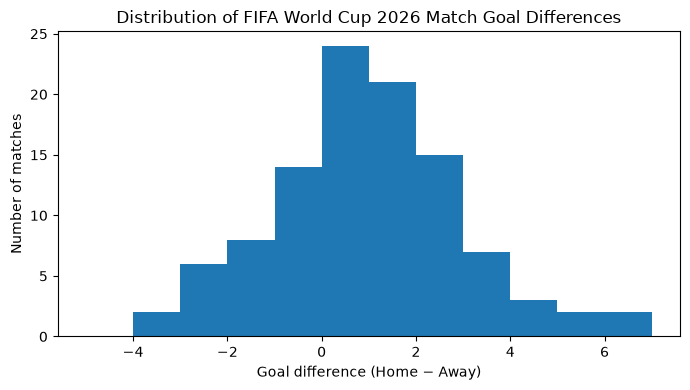

In [8]:
plt.figure(figsize=(7,4))
plt.hist(df["Goal_Difference"], bins=range(int(df["Goal_Difference"].min())-1,
                                           int(df["Goal_Difference"].max())+2))
plt.xlabel("Goal difference (Home − Away)")
plt.ylabel("Number of matches")
plt.title("Distribution of FIFA World Cup 2026 Match Goal Differences")
plt.tight_layout()
plt.show()


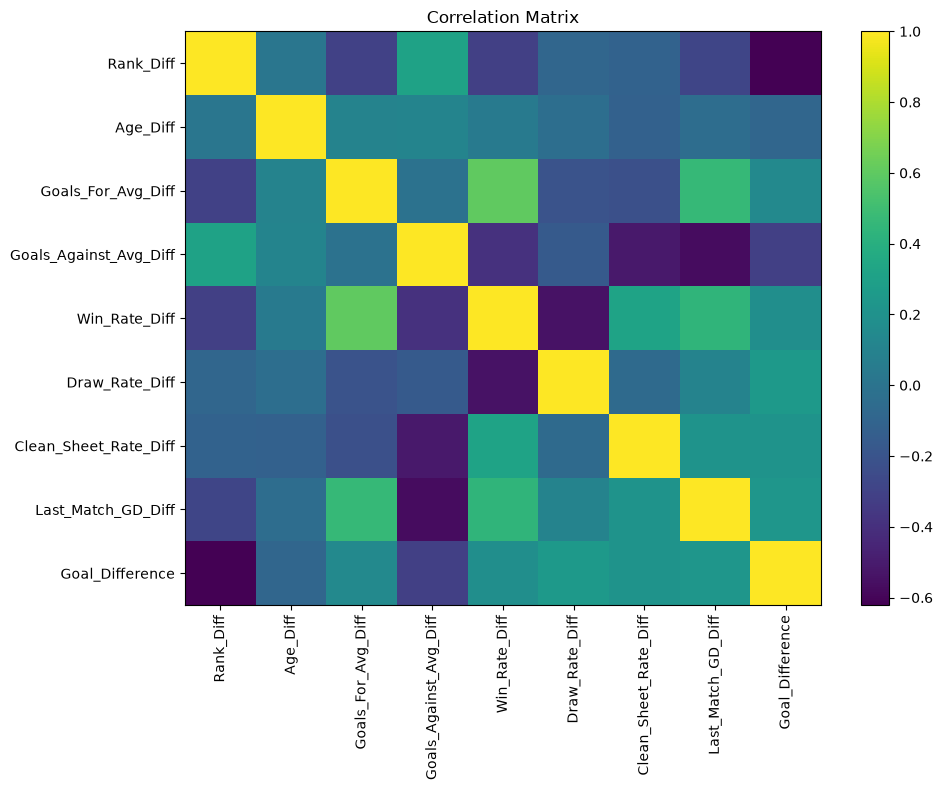

In [9]:
corr = df[predictors + ["Goal_Difference"]].corr()
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)), corr.index)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 6. Chronological train/test split
The first 83 matches (~80%) are used for training and the final 21 matches for testing. A chronological split is used because the practical objective is to predict later matches from earlier information, rather than randomly mixing later tournament matches into training.


In [10]:
X = df[predictors]
y = df["Goal_Difference"]
split = 83
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(X_train.shape, X_test.shape)


(83, 8) (21, 8)


## 7. Competing linear algorithms
Ordinary Least Squares (OLS), Ridge and Lasso are evaluated using the same hold-out matches. MAE and RMSE are lower-is-better; R² is higher-is-better.


In [11]:
models = {
    "OLS Linear Regression": LinearRegression(),
    "Ridge Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 100)))
    ]),
    "Lasso Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LassoCV(alphas=np.logspace(-3, 1, 100), cv=5,
                          random_state=RANDOM_STATE, max_iter=20000))
    ])
}

results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df.round(3)


,Model,MAE,RMSE,R2
2,Lasso Regression,1.191,1.516,0.020
1,Ridge Regression,1.205,1.533,-0.003
0,OLS Linear Regression,1.236,1.541,-0.013


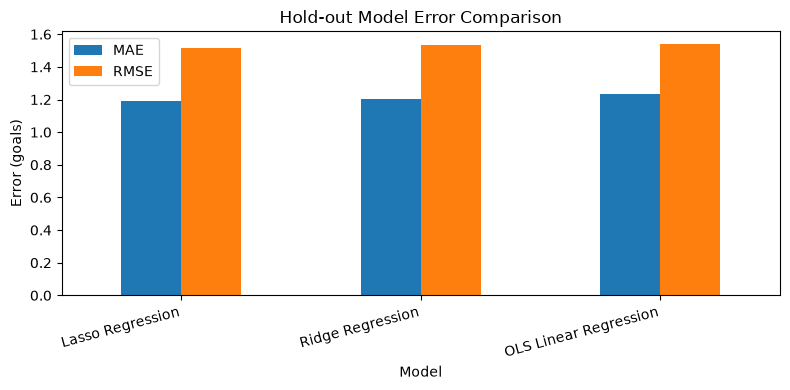

In [12]:
ax = results_df.set_index("Model")[["MAE","RMSE"]].plot(kind="bar", figsize=(8,4))
ax.set_ylabel("Error (goals)")
ax.set_title("Hold-out Model Error Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 8. Actual vs predicted and residual diagnostics
The best model should be selected from the hold-out evidence, not from training fit. Low or negative hold-out R² is a meaningful result: it indicates that the eight pre-match variables explain little of the variation in unseen match goal differences.


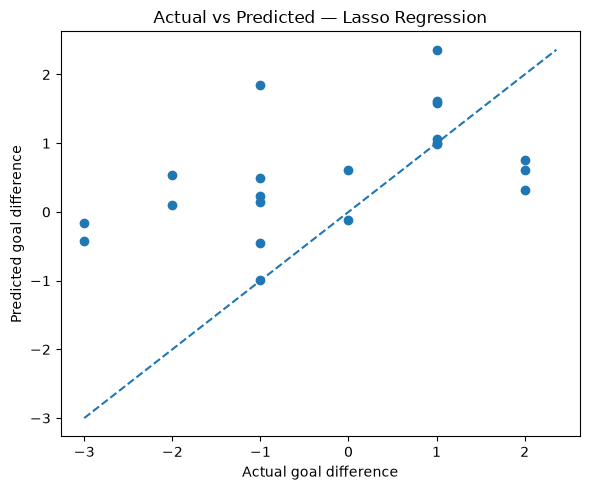

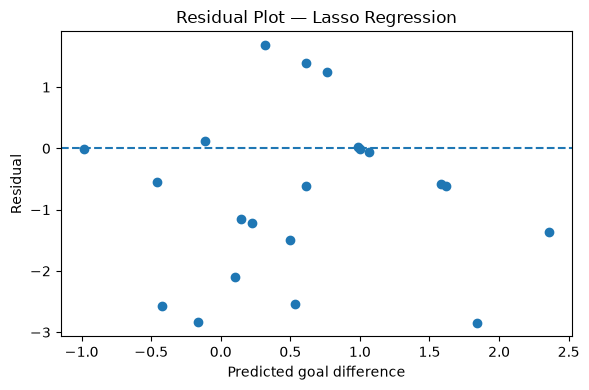

In [13]:
best_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_name]

plt.figure(figsize=(6,5))
plt.scatter(y_test, best_pred)
lo = min(y_test.min(), best_pred.min()); hi = max(y_test.max(), best_pred.max())
plt.plot([lo,hi],[lo,hi],"--")
plt.xlabel("Actual goal difference")
plt.ylabel("Predicted goal difference")
plt.title(f"Actual vs Predicted — {best_name}")
plt.tight_layout()
plt.show()

residuals = y_test.to_numpy() - best_pred
plt.figure(figsize=(6,4))
plt.scatter(best_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted goal difference")
plt.ylabel("Residual")
plt.title(f"Residual Plot — {best_name}")
plt.tight_layout()
plt.show()


## 9. OLS coefficients and multicollinearity
VIF values are inspected to identify whether predictors contain substantial redundant linear information. This is also why Ridge and Lasso are included as competing regularised linear models.


In [14]:
ols_stats = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(ols_stats.summary())

vif = pd.DataFrame({
    "Predictor": predictors,
    "VIF": [variance_inflation_factor(X_train.to_numpy(), i) for i in range(len(predictors))]
})
vif.round(2)


                            OLS Regression Results                            
Dep. Variable:        Goal_Difference   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     9.090
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           1.31e-08
Time:                        22:20:58   Log-Likelihood:                -150.36
No. Observations:                  83   AIC:                             318.7
Df Residuals:                      74   BIC:                             340.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

,Predictor,VIF
0,Rank_Diff,1.28
1,Age_Diff,1.04
2,Goals_For_Avg_Diff,3.74
3,Goals_Against_Avg_Diff,2.95
4,Win_Rate_Diff,4.66
5,Draw_Rate_Diff,2.03
6,Clean_Sheet_Rate_Diff,1.96
7,Last_Match_GD_Diff,2.58


## 10. Interpretation and limitations

The hold-out metrics should be interpreted as predictive performance on the final 21 tournament matches. A modest R² is not a coding failure: football scores contain substantial randomness and important information (injuries, line-ups, tactics, red cards, in-match events) is deliberately excluded because the brief requires pre-match predictors.

Key limitations:
- only 104 matches are available;
- early tournament-form variables are sparse and are zero for first matches;
- ranking and squad age are static pre-tournament measures;
- the model predicts a continuous goal difference even though actual goals are discrete;
- knockout matches may differ structurally from group-stage matches;
- association does not establish causation.

The processed dataset can be exported with:
`df.to_csv("regression_2_1_processed.csv", index=False)`


## 11. Conclusion

The analysis was conducted on eight pre-match explanatory variables and used for forecasting goal difference in the 104 matches of the FIFA World Cup 2026. The results of three regression approaches namely OLS Linear Regression, Ridge Regression and Lasso Regression were compared through chronological splitting of training and testing data. The lowest test RMSE was obtained by Lasso Regression which yielded an RMSE of about 1.516 goals, MAE of about 1.191 goals and R² of about 0.020.

As the R² value is low, this means that the model accounts for only a small amount of the variation in the goal difference for the unseen matches. Thus, the team strength and previous tournament results in the pre-match variables selected were not enough to accurately predict the match goal difference individually. However, factors not included in the model, such as team selection, tactics, injuries etc. during the game, also affects the outcome of football.

The overall results prove that pre-match information can be included in a reproducible regression model, although predicting the outcome of World Cup matches with only 8 variables and a relatively small data set is challenging.

## References
- FBref, *2026 World Cup Scores & Fixtures*: https://fbref.com/en/comps/1/schedule/schedule-Stats
- MLS Soccer, *FIFA World Rankings: Every team at the 2026 World Cup* (rankings as of 11 June 2026): https://www.mlssoccer.com/competitions/fifa-world-cup/news/fifa-world-rankings-every-team-at-the-world-cup
- FIFA, *The squads in stats*: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/numbers-squads-stats
- Pantheonic, *The Tournament of Global Unity — FIFA World Cup 2026* (official-squad age table): https://www.pantheonic.cloud/publication/PI_WC2026_Full_Document.html
